In [14]:
# Importing Dependencies
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

### Linear Regression

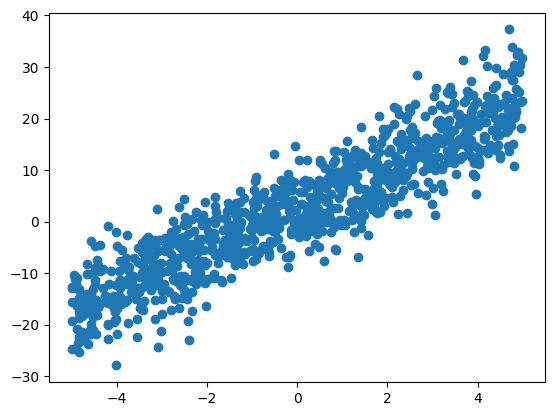

In [15]:
# Generate Random Data
n = 1000
X = 10* np.random.random(n) - 5 # X in range (-5, 5)
Y = 4*X + 3 + np.random.normal(loc = 0, scale = 5, size = n) #Y is generated from the equation: Y = 4X + 3 + noise where noise is Gaussian with mean 0 and std deviation 5.

plt.figure()
plt.scatter(
    X,
    Y
)


MSE:  24.605804056845233


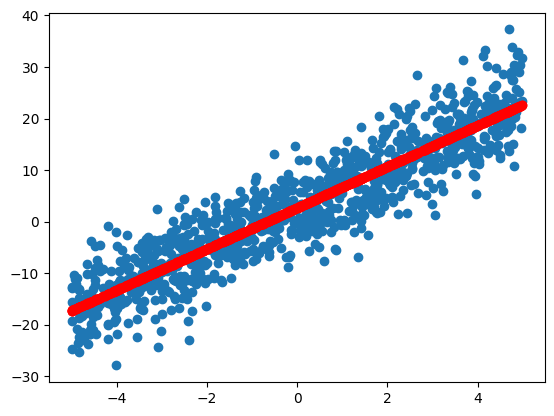

In [16]:
def Y_based_on_X(x,a,b):
  return a*x +b

# Gradient Descent
a,b = 0,0
l = 0.01

def compute_loss(X, Y, a, b):
  return np.mean((Y - Y_based_on_X(X,a,b))**2)/2
#define your descend function here
def GD(X, Y, a, b, l, n):
  n = len(X)
  for i in range(n):
    Y_pred = Y_based_on_X(X,a,b)
    error = Y_pred - Y
    grad_a = (1/n) * np.dot(X.T, error)
    grad_b = (1/n) * np.sum(error)
    a = a - l * grad_a
    b = b - l * grad_b
  return a, b

a, b = GD(X, Y, a, b, l, 1000)
mse = mean_squared_error(Y, Y_based_on_X(X,a,b))
print("MSE: ", mse)

plt.figure()
plt.scatter(
    X,
    Y
)

plt.scatter(X,Y_based_on_X(X,a,b),c = "red")
plt.show()

As you can see the values that we get for the model are extremely close to the 3 and 4 parameters that we initially set up.

TO TRY:
1. Try varying n and see how that affects the accuracy.
2. Implement the same using GD.
3. Implement the same using SGD with m = 100 and n = 1000.

In [17]:
def SGD(X, Y, a, b, l, iter, batch_size):
  n = len(X)
  for i in range(iter):
    for j in range(0, n, batch_size):
      X_batch = X[j:j+batch_size]
      Y_batch = Y[j:j+batch_size]
      Y_pred = Y_based_on_X(X_batch, a, b)
      error = Y_pred - Y_batch
      a = a - l * (1/batch_size) * np.dot(X_batch.T, error)
      b = b - l * (1/batch_size) * np.sum(error)
  return a, b

In [18]:
def generate_data(n):
  X = 10* np.random.random(n) - 5 # X in range (-5, 5)
  Y = 4*X + 3 + np.random.normal(loc = 0, scale = 5, size = n)
  return X, Y

MSE(SGD):  24.61330271787168


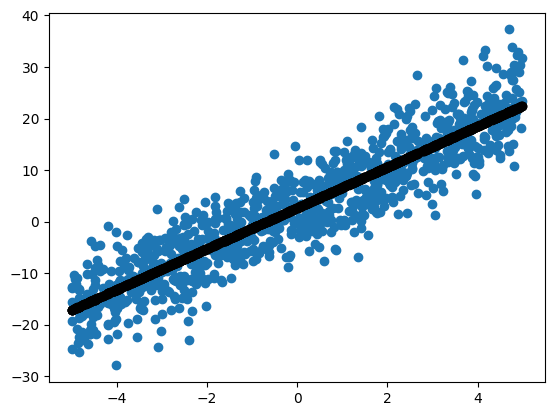

In [19]:
a,b = SGD(X, Y, a, b, l, 1000, 100)
mse = mean_squared_error(Y, Y_based_on_X(X,a,b))
print("MSE(SGD): ", mse)
plt.figure()
plt.scatter(
    X,
    Y
)
plt.scatter(X,Y_based_on_X(X,a,b),c = "black")
plt.show()

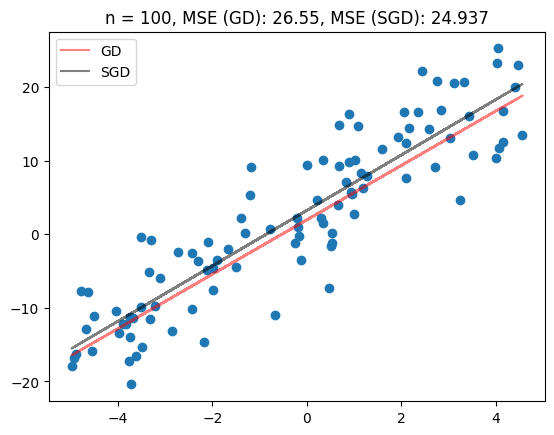

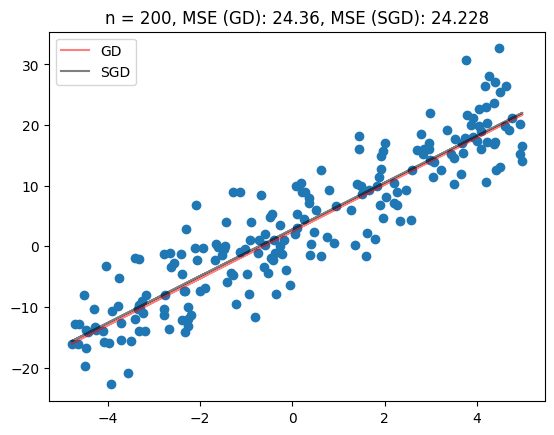

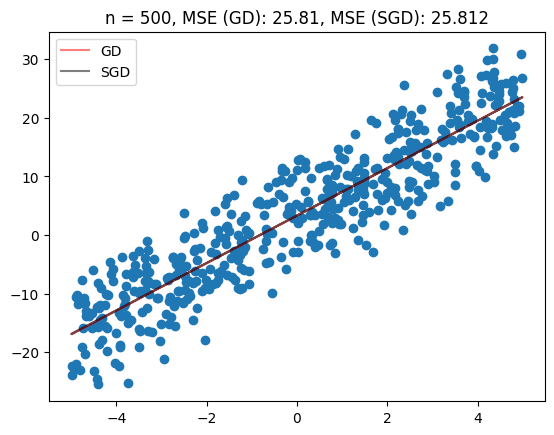

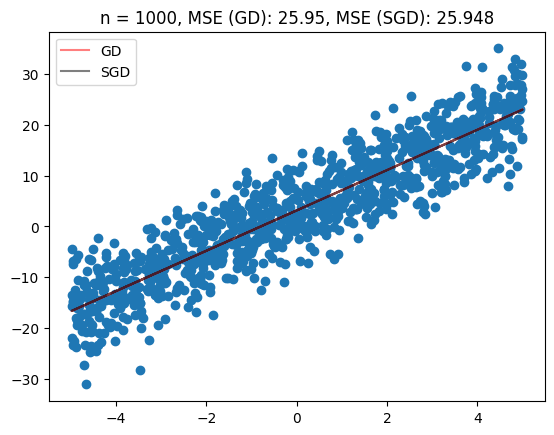

In [21]:
n = [100, 200, 500, 1000]
for i in n:
  X, Y = generate_data(i)
  a,b = 0,0
  l = 0.01
  aGD,bGD = GD(X, Y, a, b, l, 1000)
  aSGD,bSGD = SGD(X, Y, a, b, l, 1000, 100)
  mse_gd = mean_squared_error(Y, Y_based_on_X(X,aGD,bGD))
  mse_sgd = mean_squared_error(Y, Y_based_on_X(X,aSGD,bSGD))

  plt.scatter(X, Y)
  plt.plot(X, Y_based_on_X(X, aGD, bGD), color='red', label='GD', alpha = 0.5)
  plt.plot(X, Y_based_on_X(X, aSGD, bSGD), color='black', label='SGD', alpha = 0.5)
  plt.title(f"n = {i}, MSE (GD): {mse_gd:.2f}, MSE (SGD): {mse_sgd:.3f}")
  plt.legend()
  plt.show()

In [22]:
# Closed form SOlution
# Go through this code. This code is just for learning the closed form solution
#This closed-form solution snippet implements Ordinary Least Squares (OLS) linear regression using matrix algebra, also known as the Normal Equation

X_0 = []
for i in range(len(X)):
  X_0.append((1,X[i]))
X = np.matrix(X_0)
Y = np.matrix(Y)
beta = (X.T*X).I*X.T*Y.T

beta

matrix([[3.15048262],
        [3.96377646]])